In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import tensorflow as tf
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split as train_test_split_s
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from config import *
from src.models import *
from src.dataset import *
from utils import *

2025-07-07 17:05:48.392531: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-07 17:05:48.425382: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-07 17:05:48.871596: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"    # ?

In [3]:
def standardize(X, means, stds):
    return (X - means[None,:,None]) / stds[None,:,None]

In [4]:
def prepare(X, channels=CHANNELS):
    Xt = np.transpose(X, (0, 2, 1))   # [N, window, channels]
    sel = Xt[..., channels]           # отбор каналов
    return sel[..., np.newaxis].astype(np.float32)

In [5]:
def train_model(model, epochs, class_weights, X_train, y_train, X_valid, y_valid,
                batch_size=BATCH_SIZE, lr=INIT_LR, decay_rate=0.9,
                save_path=None, patience=PATIENCE):
    callbacks = [tf.keras.callbacks.EarlyStopping('val_loss', mode='min', patience=patience)]
    if save_path:
        callbacks.append(
            tf.keras.callbacks.ModelCheckpoint(
                save_path, monitor='val_loss',
                save_best_only=True, save_weights_only=True,
                mode='min', verbose=1
            )
        )
    steps = (len(X_train) / batch_size) * 1.5
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        lr, decay_steps=steps, decay_rate=decay_rate
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss='sparse_categorical_crossentropy', metrics=['accuracy']
    )
    return model.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=1  # чтобы был прогресс-бар
    )

# Continuous dataset

In [6]:
WINDOW_SIZE = 56

In [7]:
GESTURE_INDEXES_MAIN

[0, 13, 15, 18, 19, 34, 38, 43, 46]

In [8]:
emgs_raw = np.load('data/continuous/emg_data_full.npy')
labels_raw = np.load('data/continuous/gesture_labels_full.npy')

In [9]:
emgs_raw.shape

(18044, 8)

In [10]:
gestures_dict = {}
for gest_i in np.unique(labels_raw):
    gestures_dict[f'{gest_i}'] = emgs_raw[np.where(labels_raw==gest_i)]

In [11]:
emgs, labels = apply_window(gestures_dict, window=WINDOW_SIZE, step=STEP_SIZE)

In [12]:
emgs.shape

(1098, 8, 56)

In [13]:
norm_file = f'../normalization_values/fold1_win{WINDOW_SIZE}_attention.json'
with open(norm_file, 'r') as f:
    params = json.load(f)

X_stand = standardize(emgs, np.array(params['mean']), np.array(params['std']))
X_input = prepare(X_stand)

In [14]:
np.std(X_input, axis=(0, 1, 3))

array([0.26760677, 0.43418324, 1.2276403 , 2.5746253 , 0.9913133 ,
       0.4787161 , 0.5557006 , 0.42300767], dtype=float32)

In [15]:
input_shape = (WINDOW_SIZE, len(CHANNELS), 1)
model = build_SAM_model(input_shape, FILTERS_BASE, KERNEL_SIZE_BASE, POOL_SIZE_BASE, P_DROPOUT_BASE, NUM_CLASSES)
model.load_weights('../' + SAVE_PATH + f'_fold1_{WINDOW_SIZE}_attention.h5')

2025-07-07 17:05:50.206773: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-07-07 17:05:50.206802: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:168] retrieving CUDA diagnostic information for host: etri3060-H610M4-PLUS
2025-07-07 17:05:50.206805: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:175] hostname: etri3060-H610M4-PLUS
2025-07-07 17:05:50.206944: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:199] libcuda reported version is: 575.57.8
2025-07-07 17:05:50.206961: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:203] kernel reported version is: 575.57.8
2025-07-07 17:05:50.206963: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:309] kernel version seems to match DSO: 575.57.8


In [16]:
model.layers

### Активные слои

In [17]:
# for layer in model.layers[:6]:
#     layer.trainable = False
model.layers[9].trainable = False

In [18]:
for layer in model.layers:
    print(f"{layer.name}: trainable = {layer.trainable}")

input_1: trainable = True
conv2d: trainable = True
batch_normalization: trainable = True
p_re_lu: trainable = True
spatial_dropout2d: trainable = True
max_pooling2d: trainable = True
conv2d_1: trainable = True
batch_normalization_1: trainable = True
p_re_lu_1: trainable = True
spatial_attention: trainable = False
batch_normalization_2: trainable = True
spatial_dropout2d_1: trainable = True
max_pooling2d_1: trainable = True
flatten: trainable = True
dense: trainable = True
softmax: trainable = True


In [19]:
X_input.shape

(1098, 56, 8, 1)

In [20]:
f1_score_real, report_real, conf_matrix_real = evaluate_metrics(model, X_input, labels)

35/35 [==============================] - 0s 4ms/step


In [21]:
f1_score_real

0.17557092221041073

<Axes: >

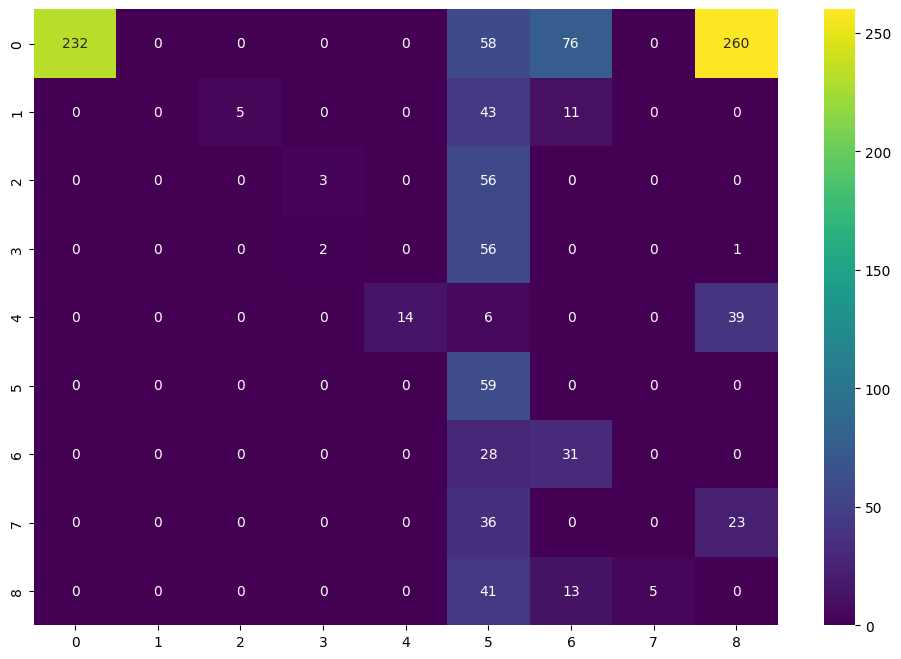

In [22]:
plt.figure(figsize=(12, 8))  # ширина=10, высота=6 дюймов
sns.heatmap(conf_matrix_real, cmap='viridis', annot=True, fmt=".0f")

In [23]:
report_real['5']

{'precision': 0.15404699738903394,
 'recall': 1.0,
 'f1-score': 0.2669683257918552,
 'support': 59.0}

In [24]:
preds = np.argmax(model.predict(X_input), axis=-1)
accuracy_score(labels, preds)

35/35 [==============================] - 0s 5ms/step


0.30783242258652094

In [25]:
X_train, X_test, y_train, y_test = train_test_split_s(X_input, labels, test_size=0.3, stratify=labels, random_state=42)

In [26]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

In [29]:
class_weights = dict(zip(np.unique(y_train), class_weights))

In [30]:
train_model(model, 500, class_weights=class_weights, X_train=X_train, y_train=y_train, X_valid=X_test, lr=1e-2, y_valid=y_test, batch_size=32, save_path=None)

Epoch 1/500
24/24 [==============================] - 1s 23ms/step - loss: 7.4352 - accuracy: 0.5195 - val_loss: 5.8838 - val_accuracy: 0.2939
Epoch 2/500
24/24 [==============================] - 0s 16ms/step - loss: 1.7663 - accuracy: 0.7083 - val_loss: 2.9386 - val_accuracy: 0.7212
Epoch 3/500
24/24 [==============================] - 0s 16ms/step - loss: 1.1392 - accuracy: 0.7448 - val_loss: 3.2880 - val_accuracy: 0.5970
Epoch 4/500
24/24 [==============================] - 0s 16ms/step - loss: 0.6734 - accuracy: 0.8320 - val_loss: 1.2992 - val_accuracy: 0.7667
Epoch 5/500
24/24 [==============================] - 0s 17ms/step - loss: 0.5146 - accuracy: 0.8581 - val_loss: 1.2471 - val_accuracy: 0.7909
Epoch 6/500
24/24 [==============================] - 0s 19ms/step - loss: 0.5077 - accuracy: 0.8294 - val_loss: 1.5493 - val_accuracy: 0.7455
Epoch 7/500
24/24 [==============================] - 0s 16ms/step - loss: 0.2959 - accuracy: 0.8815 - val_loss: 0.9176 - val_accuracy: 0.8121
Epoch 

In [ ]:
f1_score_real, report_real, conf_matrix_real = evaluate_metrics(model, X_test, y_test)

11/11 [==============================] - 0s 5ms/step


In [ ]:
f1_score_real

0.7506209889256504

<Axes: >

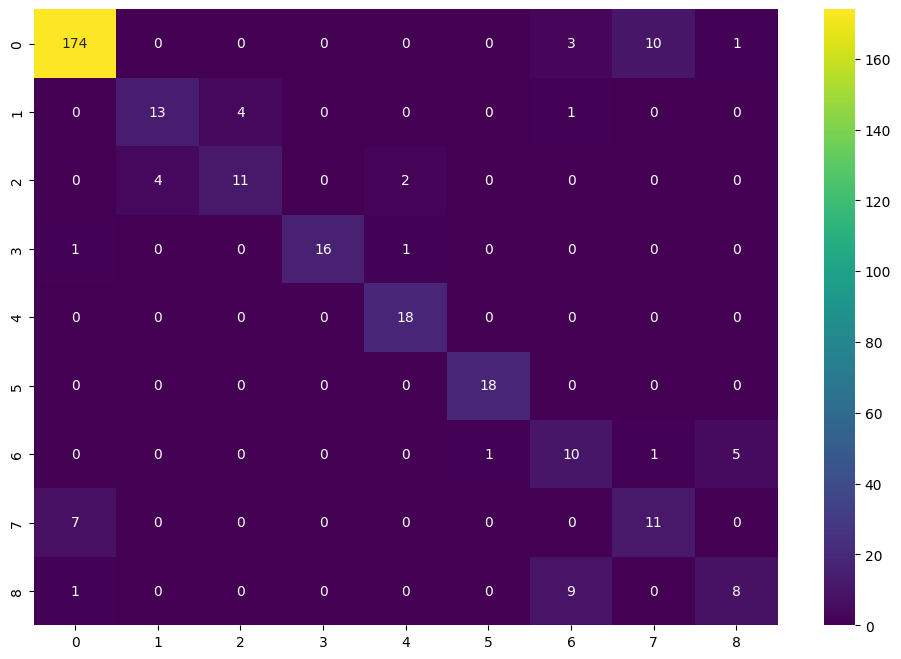

In [ ]:
plt.figure(figsize=(12, 8)) 
sns.heatmap(conf_matrix_real, cmap='viridis', annot=True, fmt=".0f")